In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [33]:
dim_date = pd.read_csv("/WINGS-Group-Trade-Marketing-Performance-Analysis/raw_data/dim_date.csv");
dim_product = pd.read_csv("/WINGS-Group-Trade-Marketing-Performance-Analysis/raw_data/dim_product.csv");
dim_outlet = pd.read_csv("/WINGS-Group-Trade-Marketing-Performance-Analysis/raw_data/dim_outlet_raw.csv");

fact_digital_campaign = pd.read_csv("/WINGS-Group-Trade-Marketing-Performance-Analysis/raw_data/fact_digital_campaign.csv");
fact_sales = pd.read_csv("/WINGS-Group-Trade-Marketing-Performance-Analysis/raw_data/fact_sales_raw.csv");
fact_promotion = pd.read_csv("/WINGS-Group-Trade-Marketing-Performance-Analysis/raw_data/fact_promotion.csv")

In [28]:
def basic_eda(df, name):
    
    print("="*50)
    print(f"Dataset: {name}")
    print("="*50)
    
    print("\nShape:")
    print(df.shape)
    
    print("\nColumns:")
    print(df.columns.tolist())
    
    print("\nData Type:")
    print(df.dtypes)
    
    print("\nFirst 5 Rows:")
    display(df.head())

In [34]:
basic_eda(dim_product, "dim_product")
basic_eda(dim_outlet, "dim_outlet")
basic_eda(dim_date, "dim_date")
basic_eda(fact_sales, "fact_sales")
basic_eda(fact_promotion, "fact_promotion")
basic_eda(fact_digital_campaign, "fact_digital_campaign")

Dataset: dim_product

Shape:
(58, 7)

Columns:
['sku_id', 'product_name', 'brand', 'category', 'sub_category', 'pack_size', 'unit_price']

Data Type:
sku_id          object
product_name    object
brand           object
category        object
sub_category    object
pack_size       object
unit_price       int64
dtype: object

First 5 Rows:


,sku_id,product_name,brand,category,sub_category,pack_size,unit_price
0,SOKLIN-DET-001,SoKlin Detergent Powder,SoKlin,Fabric Care,Powder Detergent,770 gr,12000
1,SOKLIN-DET-002,SoKlin Liquid Detergent,SoKlin,Fabric Care,Liquid Detergent,450 gr,18000
2,SOKLIN-GEN-001,SoKlin Softener,SoKlin,Fabric Care,Fabric Softener,800 ml,15000
3,SOKLIN-GEN-002,SoKlin Pewangi,SoKlin,Fabric Care,Fabric Fragrance,450 gr,9000
4,DAIA-DET-001,Daia Detergent Powder,Daia,Fabric Care,Powder Detergent,800 ml,10000


Dataset: dim_outlet

Shape:
(1185, 10)

Columns:
['outlet_id', 'outlet_name', 'channel', 'outlet_type', 'chain_name', 'region', 'province', 'city', 'tier', 'status']

Data Type:
outlet_id      object
outlet_name    object
channel        object
outlet_type    object
chain_name     object
region         object
province       object
city           object
tier           object
status         object
dtype: object

First 5 Rows:


,outlet_id,outlet_name,channel,outlet_type,chain_name,region,province,city,tier,status
0,OUT000001,Indomaret Solo 1,Modern Trade,Minimarket,Indomaret,Jawa,Jawa Tengah,Solo,A,Active
1,OUT000002,Indomaret Batam 2,Modern Trade,Minimarket,Indomaret,Sumatera,Kepulauan Riau,Batam,A,Active
2,OUT000003,Indomaret Yogyakarta 3,Modern Trade,Minimarket,Indomaret,Jawa,DI Yogyakarta,Yogyakarta,B,Active
3,OUT000004,Indomaret Mataram 4,Modern Trade,Minimarket,Indomaret,Bali-Nusa,Nusa Tenggara Barat,Mataram,A,Active
4,OUT000005,Indomaret Palangkaraya 5,Modern Trade,Minimarket,Indomaret,Kalimantan,Kalimantan Tengah,Palangkaraya,A,Active


Dataset: dim_date

Shape:
(1461, 5)

Columns:
['date_id', 'date', 'month', 'quarter', 'year']

Data Type:
date_id     int64
date       object
month       int64
quarter    object
year        int64
dtype: object

First 5 Rows:


...

,transaction_id,date_id,outlet_id,sku_id,quantity,gross_sales,discount,net_sales
0,TRX000000001,20260131,OUT000553,HERSPROTEX-GEN-001,38.0,380000,19000.0,361000
1,TRX000000002,20261230,OUT000107,CLING-GEN-001,16.0,192000,1920.0,190080
2,TRX000000003,20250510,OUT000780,SEDAAP-GEN-002,662.0,1986000,59580.0,1926420
3,TRX000000004,20260718,OUT000271,WINGS-DET-001,144.0,1152000,57600.0,1094400
4,TRX000000005,20260204,OUT000213,BOOM-DET-001,134.0,938000,18760.0,919240


Dataset: fact_promotion

Shape:
(80000, 8)

Columns:
['promotion_id', 'sku_id', 'outlet_id', 'promo_type', 'start_date', 'end_date', 'discount_percentage', 'promo_budget']

Data Type:
promotion_id            object
sku_id                  object
outlet_id               object
promo_type              object
start_date              object
end_date                object
discount_percentage    float64
promo_budget           float64
dtype: object

First 5 Rows:


,promotion_id,sku_id,outlet_id,promo_type,start_date,end_date,discount_percentage,promo_budget
0,PROMO000001,SYSTEMA-GEN-001,OUT000320,Price Discount,2024-07-13,2024-07-27,13.0,37868828.0
1,PROMO000002,EKONOMI-GEN-001,OUT000326,Bundle Promo,2026-07-31,2026-08-18,8.0,95825067.0
2,PROMO000003,ISOPLUS-DRINK-001,OUT000897,Carton Promo,2023-12-07,2023-12-23,28.0,123258777.0
3,PROMO000004,EKONOMI-GEN-001,OUT000148,Price Discount,2026-07-25,2026-08-08,7.0,34345092.0
4,PROMO000005,MIESEDAAP-GEN-001,OUT000198,Bundle Promo,2026-05-26,2026-06-25,5.0,80329037.0


Dataset: fact_digital_campaign

Shape:
(48844, 12)

Columns:
['campaign_id', 'sku_id', 'platform', 'campaign_type', 'start_date', 'end_date', 'spend', 'impressions', 'clicks', 'engagement', 'ctr', 'conversion_rate']

Data Type:
campaign_id         object
sku_id              object
platform            object
campaign_type       object
start_date          object
end_date            object
spend                int64
impressions          int64
clicks             float64
engagement           int64
ctr                float64
conversion_rate    float64
dtype: object

First 5 Rows:


,campaign_id,sku_id,platform,campaign_type,start_date,end_date,spend,impressions,clicks,engagement,ctr,conversion_rate
0,CMP000001,SYSTEMA-GEN-001,Facebook,Brand Awareness,2026-03-22,2026-06-07,300310485,8227207,87046.0,627591,1.06,5.74
1,CMP000002,SOKLIN-GEN-001,YouTube,Product Launch,2023-04-01,2023-05-15,458035110,1076449,6184.0,31946,0.57,4.54
2,CMP000003,FROSTBITE-ICE-001,TikTok,Ramadan Campaign,2025-07-28,2025-09-18,702808098,18295201,283355.0,922605,1.55,2.95
3,CMP000004,SEGARDINGIN-GEN-001,YouTube,Promo Campaign,2024-01-08,2024-02-28,458778756,11426912,136514.0,335702,1.19,6.34
4,CMP000005,HERSPROTEX-GEN-001,TikTok,Influencer Campaign,2026-11-25,2026-12-08,390451171,11551238,232100.0,954612,2.01,6.11


In [35]:
def missing_check(df, name):
    
    missing = df.isnull().sum()
    
    missing_percentage = (
        df.isnull().sum() / len(df) * 100
    )
    
    result = pd.DataFrame({
        "Missing Value": missing,
        "Percentage (%)": missing_percentage
    })
    
    result = result[result["Missing Value"] > 0]
    
    print(f"Missing Value Check - {name}")
    
    return result

In [36]:
missing_check(dim_product,"dim_product")
missing_check(dim_outlet,"dim_outlet")
missing_check(dim_date,"dim_date")
missing_check(fact_sales,"fact_sales")
missing_check(fact_promotion,"fact_promotion")
missing_check(fact_digital_campaign,"fact_digital_campaign")

Missing Value Check - dim_product
Missing Value Check - dim_outlet
Missing Value Check - dim_date
Missing Value Check - fact_sales
Missing Value Check - fact_promotion
Missing Value Check - fact_digital_campaign


,Missing Value,Percentage (%)
clicks,50,0.102367
ctr,50,0.102367


In [41]:
dim_product.isnull().sum()

sku_id          0
product_name    0
brand           0
category        0
sub_category    0
pack_size       0
unit_price      0
dtype: int64

In [42]:
dim_outlet.isnull().sum()

outlet_id      0
outlet_name    0
channel        0
outlet_type    0
chain_name     0
region         0
province       0
city           0
tier           0
status         0
dtype: int64

In [43]:
dim_date.isnull().sum()

date_id    0
date       0
month      0
quarter    0
year       0
dtype: int64

In [44]:
fact_promotion.isnull().sum()

promotion_id            0
sku_id                  0
outlet_id               0
promo_type              0
start_date              0
end_date                0
discount_percentage    50
promo_budget           30
dtype: int64

In [45]:
fact_digital_campaign.isnull().sum()

campaign_id         0
sku_id              0
platform            0
campaign_type       0
start_date          0
end_date            0
spend               0
impressions         0
clicks             50
engagement          0
ctr                50
conversion_rate     0
dtype: int64

In [46]:
fact_sales.isnull().sum()

transaction_id      0
date_id             0
outlet_id          20
sku_id              0
quantity           50
gross_sales         0
discount          100
net_sales           0
dtype: int64

In [47]:
def duplicate_check(df, name):
    
    duplicate = df.duplicated().sum()
    
    print(f"""
Dataset:
{name}

Duplicate Rows:
{duplicate}

Duplicate Percentage:
{duplicate/len(df)*100:.2f}%
""")

In [48]:
duplicate_check(dim_product,"dim_product")

duplicate_check(dim_outlet,"dim_outlet")

duplicate_check(dim_date,"dim_date")

duplicate_check(fact_sales,"fact_sales")

duplicate_check(fact_promotion,"fact_promotion")

duplicate_check(fact_digital_campaign,"fact_digital_campaign")


Dataset:
dim_product

Duplicate Rows:
0

Duplicate Percentage:
0.00%


Dataset:
dim_outlet

Duplicate Rows:
0

Duplicate Percentage:
0.00%


Dataset:
dim_date

Duplicate Rows:
0

Duplicate Percentage:
0.00%


Dataset:
fact_sales

Duplicate Rows:
68

Duplicate Percentage:
0.00%


Dataset:
fact_promotion

Duplicate Rows:
0

Duplicate Percentage:
0.00%


Dataset:
fact_digital_campaign

Duplicate Rows:
0

Duplicate Percentage:
0.00%



In [49]:
dim_product.nunique()

sku_id          58
product_name    58
brand           47
category         7
sub_category    34
pack_size       15
unit_price      19
dtype: int64

In [50]:
dim_outlet.nunique()

outlet_id      1185
outlet_name    1056
channel           3
outlet_type       7
chain_name       17
region            8
province         26
city             39
tier              3
status            1
dtype: int64

In [52]:
dim_product["sku_id"].duplicated().sum()

np.int64(0)

In [53]:
dim_outlet["outlet_id"].duplicated().sum()

np.int64(0)

In [55]:
dim_date["date_id"].duplicated().sum()

np.int64(0)

In [56]:
fact_sales.describe()

,date_id,quantity,discount,net_sales
count,1.435457e+06,1.435407e+06,1.435357e+06,1.435457e+06
mean,2.024566e+07,2.356388e+02,5.232145e+04,1.726863e+06
std,1.118071e+04,3.316478e+02,1.867908e+05,3.145925e+06
min,2.023010e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.024010e+07,4.500000e+01,1.920000e+03,2.217600e+05
50%,2.024123e+07,1.180000e+02,1.184000e+04,6.498000e+05
75%,2.025123e+07,2.580000e+02,4.230000e+04,1.796850e+06
max,2.026123e+07,4.124000e+03,1.837836e+07,5.597580e+07


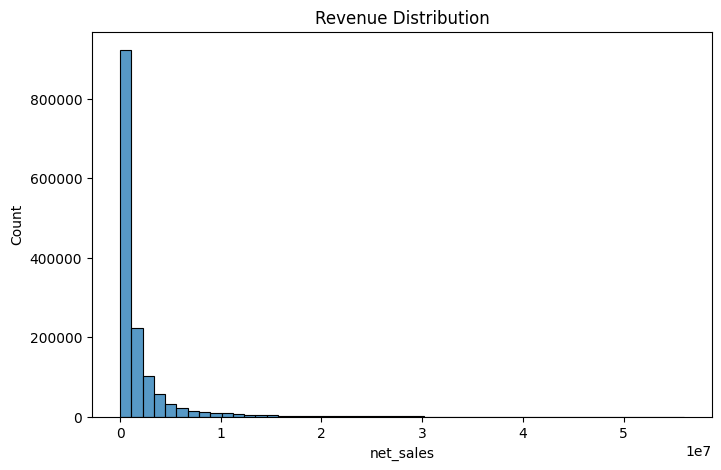

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(
    fact_sales["net_sales"],
    bins=50
)

plt.title("Revenue Distribution")
plt.show()

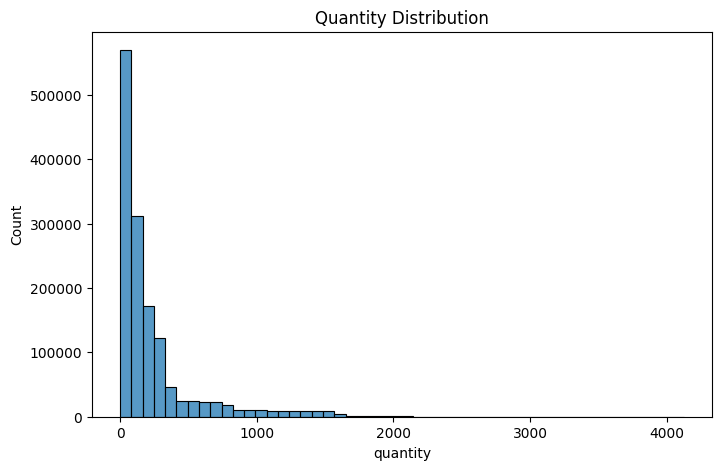

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    fact_sales["quantity"],
    bins=50
)

plt.title("Quantity Distribution")
plt.show()

In [68]:
sales_category = (
    fact_sales
    .merge(dim_product,
           on="sku_id")
    .groupby("category")
    ["net_sales"]
    .sum()
    .sort_values(
        ascending=False
    )
)

sales_category

category
Fabric Care      602487303620
Personal Care    571750108795
Home Care        416216019380
Snack            302285144710
Food             274129366795
Beverage         218455799565
Baby Care         93326807500
Name: net_sales, dtype: int64

In [70]:
sales_category = (
    fact_sales
    .merge(dim_outlet,
           on="outlet_id")
    .groupby("channel")
    ["net_sales"]
    .sum()
    .sort_values(
        ascending=False
    )
)

sales_category

channel
Wholesale       1643874736565
Modern Trade     815995681780
E-Commerce        18947625720
Name: net_sales, dtype: int64

In [71]:
top_sku = (
    fact_sales
    .merge(dim_product,
           on="sku_id")
    .groupby("product_name")
    ["net_sales"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_sku

product_name
Kecap Sedaap                105493065450
SoKlin Liquid Detergent     103479848460
Baby Happy Diaper            93326807500
Serasoft Shampoo             92557476000
SoKlin Softener              85927164300
WPC Toilet Cleaner           82417429360
Zinc Shampoo                 75429785060
WIZ Disinfectant             73918504350
SoKlin Detergent Powder      70608748320
Ekonomi Liquid Detergent     69685710600
Name: net_sales, dtype: int64